In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
V_arr = np.array([
    0, 1, 1.5, 2,
    2.5, 3, 3.5, 4,
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.50 + 1e-12, 0.005),
])  # 108 temps total


V_num = len(V_arr)
temps_num = len(temps)

In [7]:
df = np.load('./data/DFPFD_mult.npz')
temps_df = df["temps"].reshape(V_num, temps_num)
F0 = df["F0"].reshape(V_num, temps_num)
F_swave = df["F_swave"].reshape((V_num, temps_num))
F_dwave = df["F_dwave"].reshape((V_num, temps_num))
F_px = df["F_px"].reshape((V_num, temps_num))
F_py = df["F_py"].reshape((V_num, temps_num))
Fuu_px = df["Fuu_px"].reshape((V_num, temps_num))
Fuu_py = df["Fuu_py"].reshape((V_num, temps_num))
Fdd_px = df["Fdd_px"].reshape((V_num, temps_num))
Fdd_py = df["Fdd_py"].reshape((V_num, temps_num))

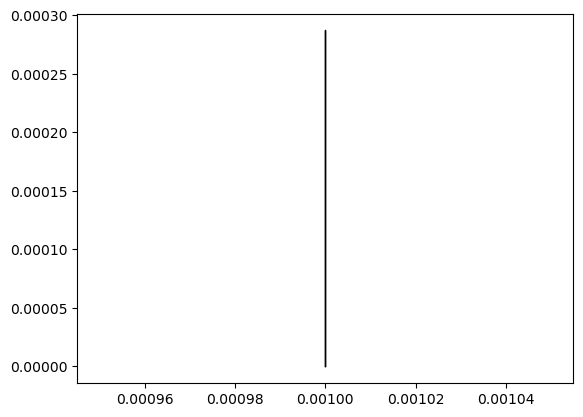

In [12]:
temps0 = temps_df[:,0]
F_px0 = F_px[:,0]

plt.plot(temps0, np.abs(F_px0), "-", linewidth=1, label=r"Bulk: $F_{p_x}$", color='black')

In [8]:
I = np.abs(np.abs(Fuu_px) + np.abs(Fdd_px)) / 2

[0.00015133 0.00048426 0.00122227 0.00230899 0.00358304 0.00476873
 0.00579012 0.00664278]


(0.0, 0.5057499999999999)

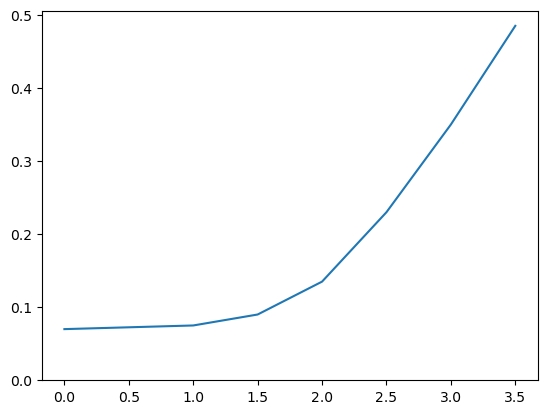

In [10]:
threshold = 0.05 * I.max(axis=1)  # shape: (n_swave,)
print(threshold)
Tc_direct = []
dwave_valid = []

for i, dw in enumerate(V_arr):
    row = I[i, :]
    above = row >= threshold[i]
    crossings = np.where(np.diff(above.astype(int)))[0]
    
    if len(crossings) > 0:
        Tc_direct.append(temps[crossings[0]])
        dwave_valid.append(dw)

Tc_s = np.array(Tc_direct)
dwave_s = np.array(dwave_valid)
Tc_s = Tc_s#/np.max(Tc_s)
plt.plot(dwave_s, Tc_s)
plt.ylim(0, None)

In [18]:
V_arr = np.array([
    0,1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,
    # 9,9.5
])

dwave_arr = np.array([
    0, 0.07912, 0.12194, 0.143596,
    0.156518, 0.16489, 0.2, 0.225, 
    0.25, 0.275, 0.3, 0.325, 0.35,
    # 0.375, 0.4
]) * V_arr

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.200 + 1e-12, 0.001),
])  # 163 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(temps_num)
print(temps_num*V_num)

print(np.where(np.isclose(dwave_arr, 0.975)))
print(dwave_arr)

163
2119
(array([], dtype=int64),)
[0.       0.07912  0.24388  0.430788 0.626072 0.82445  1.1      1.35
 1.625    1.925    2.25     2.6      2.975   ]


In [19]:
df = np.load('./data/DFP_hx_mult.npz')
temps_df = df["temps"].reshape(V_num, temps_num)
F0 = df["F0"].reshape(V_num, temps_num)
F_swave = df["F_swave"].reshape((V_num, temps_num))
F_dwave = df["F_dwave"].reshape((V_num, temps_num))
F_px = df["F_px"].reshape((V_num, temps_num))
F_py = df["F_py"].reshape((V_num, temps_num))
Fuu_px = df["Fuu_px"].reshape((V_num, temps_num))
Fuu_py = df["Fuu_py"].reshape((V_num, temps_num))
Fdd_px = df["Fdd_px"].reshape((V_num, temps_num))
Fdd_py = df["Fdd_py"].reshape((V_num, temps_num))

In [20]:
I1 = np.abs(np.abs(Fuu_px) + np.abs(Fdd_px)) / 2

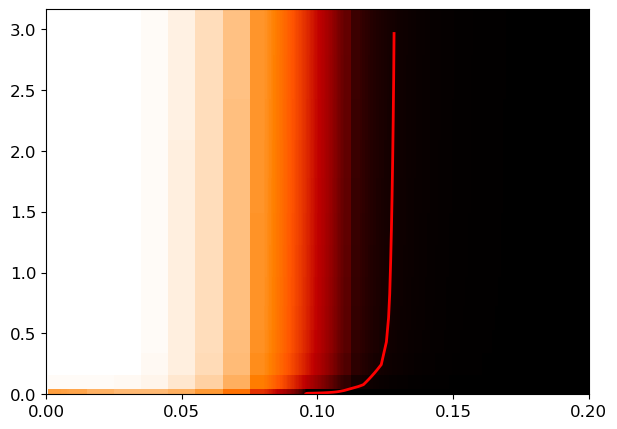

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# intensity

# threshold
threshold = 0.05 * I1.max()
threshold2 = 0.01 * I1.max()
vmin = 0
vmax = max(I1.max(), I2.max())

fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I1,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

# red contour line
ax.contour(
    temps,
    dwave_arr,
    I1,
    levels=[threshold],
    colors='red',
    linewidths=2,
    vmax=vmax
)

ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

# labels
# ax.set_xlabel(r'$T/t$', fontsize=15)
# ax.set_ylabel(r'$\Delta_d$', fontsize=15)
ax.tick_params(labelsize=12)
# colorbar
# cbar = fig.colorbar(pcm, ax=ax)
# cbar.set_label(
#     r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$',
#     fontsize = 18 
# )
# cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
# cbar.ax.tick_params(labelsize=12)
plt.ylim(0, None)
plt.savefig('../../figures/DFP_mult.pdf', bbox_inches='tight')
plt.show()

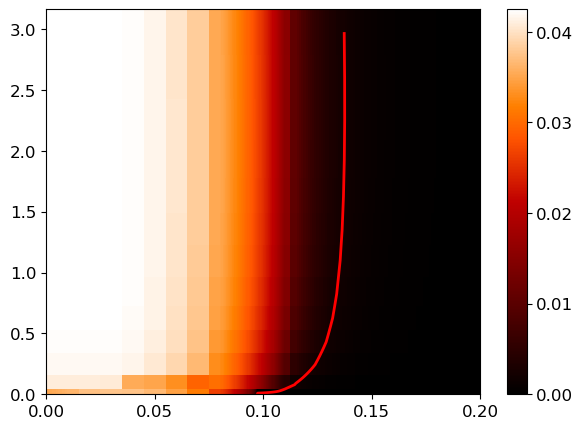

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# threshold
threshold = 0.05 * I2.max()
threshold2 = 0.01 * I2.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    swave_arr,
    I2,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

# red contour line
ax.contour(
    temps,
    swave_arr,
    I2,
    levels=[threshold],
    colors='red',
    linewidths=2,
    vmax=vmax
)

ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

ax.tick_params(labelsize=12)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
cbar.ax.tick_params(labelsize=12)
plt.ylim(0, None)
plt.savefig('../../figures/SFP_mult.pdf', bbox_inches='tight')
plt.show()

C:\Users\emoeu\AppData\Local\Temp\ipykernel_17252\1930236444.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


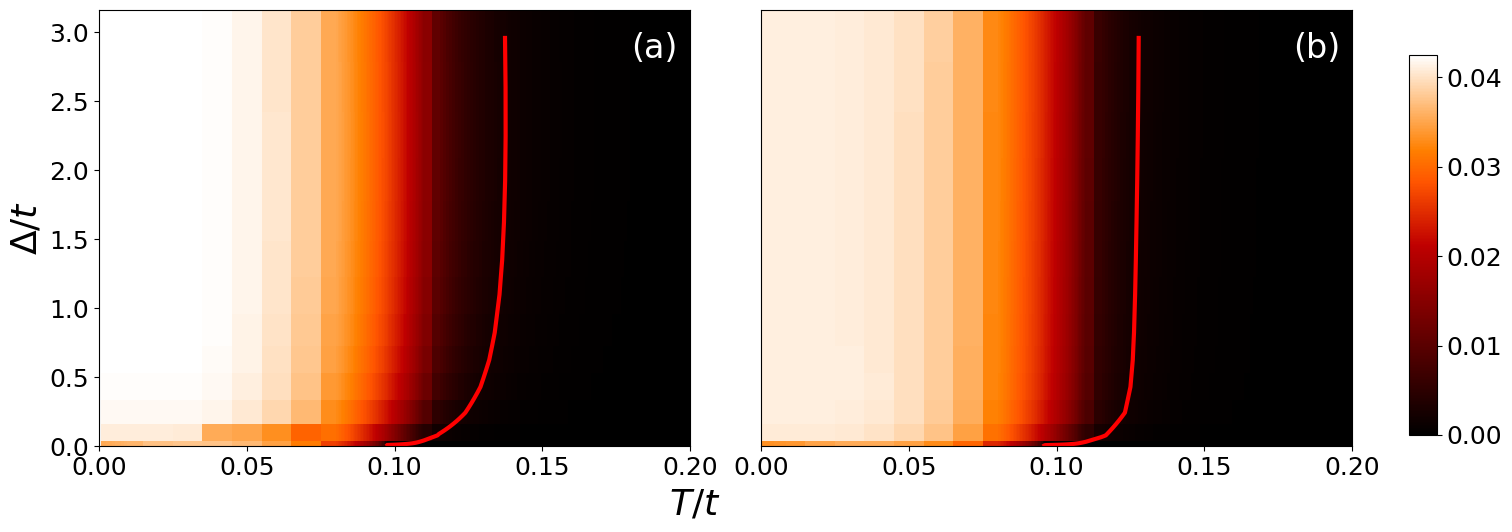

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- left: S-wave ---
pcm = ax1.pcolormesh(temps, swave_arr, I2, shading='auto', cmap='gist_heat', vmin=vmin, vmax=vmax)
ax1.contour(temps, swave_arr, I2, levels=[threshold], colors='red', linewidths=3)
ax1.set_xlim(0, 0.2)
ax1.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])
ax1.tick_params(labelsize=18)
ax1.set_ylim(0, None)
ax1.set_ylabel(r'$\Delta/t$', fontsize=26)

# --- right: D-wave ---
pcm2 = ax2.pcolormesh(temps, dwave_arr, I1, shading='auto', cmap='gist_heat', vmin=vmin, vmax=vmax)
ax2.contour(temps, dwave_arr, I1, levels=[threshold], colors='red', linewidths=3)
ax2.set_xlim(0, 0.2)
ax2.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])
ax2.set_yticks([])
ax2.tick_params(labelsize=18)
ax2.set_ylim(0, None)

ax1.text(0.9, 0.95, '(a)', transform=ax1.transAxes, fontsize=24, va='top', color='white')
ax2.text(0.9, 0.95, '(b)', transform=ax2.transAxes, fontsize=24, va='top', color='white')

# colorbar in its own dedicated axes so it doesn't squeeze ax2
cbar_ax = fig.add_axes([1.01, 0.12, 0.02, 0.76])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm2, cax=cbar_ax)
cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
cbar.ax.tick_params(labelsize=18)

# common x label
fig.text(0.5, -0.04, r'$T/t$', ha='center', fontsize=26)

plt.tight_layout()
plt.savefig('../../figures/FP_mult.pdf', bbox_inches='tight')
plt.show()

[0.00176994 0.00203704 0.00205385 0.0020549  0.00205354 0.00205231
 0.00205137 0.00205108 0.00205111 0.00205134 0.00205164 0.00205189
 0.00205204]


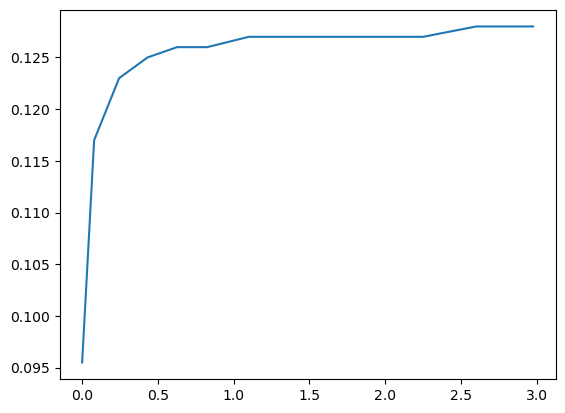

In [27]:
threshold = 0.05 * I1.max(axis=1)  # shape: (n_swave,)
print(threshold)
Tc_direct = []
dwave_valid = []

for i, dw in enumerate(swave_arr):
    row = I1[i, :]
    above = row >= threshold[i]
    crossings = np.where(np.diff(above.astype(int)))[0]
    
    if len(crossings) > 0:
        Tc_direct.append(temps[crossings[0]])
        dwave_valid.append(dw)

Tc_d = np.array(Tc_direct)
dwave_d = np.array(dwave_valid)
Tc_d = Tc_d#/np.max(Tc_s)
plt.plot(dwave_d, Tc_d)

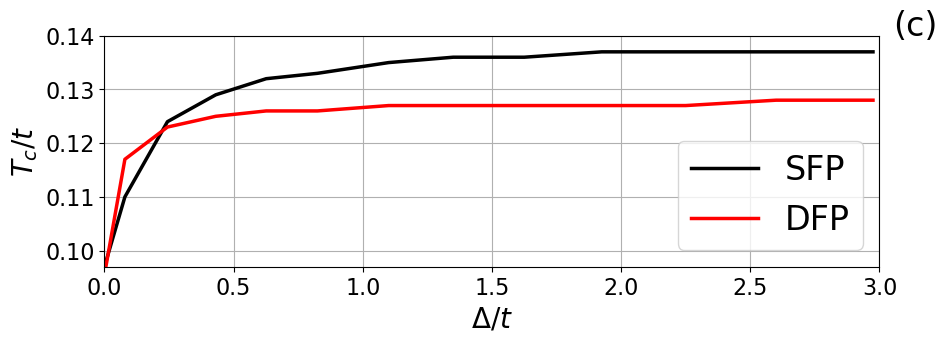

In [46]:
plt.figure(figsize=(10, 3))
plt.plot(swave_arr, Tc_s, color='black', lw=2.5, label="SFP")
plt.plot(dwave_arr, Tc_d, color='red', lw=2.5, label="DFP")
plt.legend(fontsize=24)
plt.xticks(fontsize=16)
plt.yticks([0.1,0.110,0.120,0.130, 0.140],fontsize=16)
plt.grid()
plt.text(3.051, 0.14, "(c)", fontsize=24)
plt.xlim(0, 3)
plt.ylim(Tc_s.min(),None)
plt.ylabel(r"$T_c/t$", fontsize=20)
plt.xlabel(r"$\Delta/t$", fontsize=20)
plt.savefig('../../figures/Tc_plots.pdf',bbox_inches='tight')
plt.show()

In [ ]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.110, 0.300 + 1e-12, 0.001),
])  # 210 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    swave_arr,
    I2,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

# red contour line
ax.contour(
    temps,
    swave_arr,
    I2,
    levels=[threshold],
    colors='red',
    linewidths=2,
    vmax=vmax
)

ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

ax.tick_params(labelsize=12)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_ticks([0.0, 0.01, 0.02, 0.03, 0.04])
cbar.ax.tick_params(labelsize=12)
plt.ylim(0, None)
plt.savefig('../../figures/SFP_mult.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I1,
    shading='auto',
    cmap='gist_heat',
)
ax.set_xlim(0, 0.2)

ax.contour(
    temps,
    dwave_arr,
    I1,
    levels=[threshold],
    colors='red',
    linewidths=2,
    vmax=vmax
)

ax.set_xlim(0, 0.2)
ax.set_xticks([0.0, 0.05, 0.1, 0.15, 0.2])

ax.tick_params(labelsize=12)
plt.ylim(0, None)
plt.savefig('../../figures/DFP_mult.pdf', bbox_inches='tight')
plt.show()

In [ ]:
df25 = np.load('./data/DFP_hx_mult_V25.npz')
temps_df25 = df25["temps"].reshape(V_num, temps_num)
F0 = df25["F0"].reshape(V_num, temps_num)
F_swave25 = df25["F_swave"].reshape((V_num, temps_num))
F_dwave25 = df25["F_dwave"].reshape((V_num, temps_num))
F_px25 = df25["F_px"].reshape((V_num, temps_num))
F_py25 = df25["F_py"].reshape((V_num, temps_num))
Fuu_px25 = df25["Fuu_px"].reshape((V_num, temps_num))
Fuu_py25 = df25["Fuu_py"].reshape((V_num, temps_num))
Fdd_px25 = df25["Fdd_px"].reshape((V_num, temps_num))
Fdd_py25 = df25["Fdd_py"].reshape((V_num, temps_num))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I25 = np.abs(Fuu_px25 - Fdd_px25) / 2

# threshold
threshold = 0.05 * I25.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I25,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df25.shape, dwave_arr.shape, I25.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I25,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [ ]:
plt.figure(1)
plt.clf()

plt.plot(temps_df[0], np.abs(Fuu_px[0]+Fdd_px[0])/2, linewidth=1, label=r"$p_x$-wave", color='black')
plt.plot(temps_df[0], np.abs(Fuu_py[0]+Fdd_py[0])/2, "--", linewidth=1, label=r"$p_x$-wave", color='red')

# plt.ylim(0,0.05)
# plt.xlim(0,0.2)
plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.10 + 1e-12, 0.01),
    np.arange(0.11, 0.30 + 1e-12, 0.01),
    np.arange(0.301, 0.450 + 1e-12, 0.001),
    np.arange(0.460, 0.500 + 1e-12, 0.01),
])  # 194 temps total


temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

In [ ]:
df30 = np.load('./data/DFP_hx_mult_V30.npz')
temps_df30 = df30["temps"].reshape(V_num, temps_num)
F0 = df30["F0"].reshape(V_num, temps_num)
F_swave30 = df30["F_swave"].reshape((V_num, temps_num))
F_dwave30 = df30["F_dwave"].reshape((V_num, temps_num))
F_px30 = df30["F_px"].reshape((V_num, temps_num))
F_py30 = df30["F_py"].reshape((V_num, temps_num))
Fuu_px30 = df30["Fuu_px"].reshape((V_num, temps_num))
Fuu_py30 = df30["Fuu_py"].reshape((V_num, temps_num))
Fdd_px30 = df30["Fdd_px"].reshape((V_num, temps_num))
Fdd_py30 = df30["Fdd_py"].reshape((V_num, temps_num))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I30 = np.abs(Fuu_px30 - Fdd_px30) / 2

# threshold
threshold = 0.05 * I30.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I30,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df30.shape, dwave_arr.shape, I30.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I30,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [ ]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.35 + 1e-12, 0.01),
    np.arange(0.355, 0.450 + 1e-12, 0.005),
    np.arange(0.451, 0.550 + 1e-12, 0.001),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
])  # 174 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

In [ ]:
df35 = np.load('./data/DFP_hx_mult_V35.npz')
temps_df35 = df35["temps"].reshape(V_num, temps_num)
F0 = df35["F0"].reshape(V_num, temps_num)
F_swave35 = df35["F_swave"].reshape((V_num, temps_num))
F_dwave35 = df35["F_dwave"].reshape((V_num, temps_num))
F_px35 = df35["F_px"].reshape((V_num, temps_num))
F_py35 = df35["F_py"].reshape((V_num, temps_num))
Fuu_px35 = df35["Fuu_px"].reshape((V_num, temps_num))
Fuu_py35 = df35["Fuu_py"].reshape((V_num, temps_num))
Fdd_px35 = df35["Fdd_px"].reshape((V_num, temps_num))
Fdd_py35 = df35["Fdd_py"].reshape((V_num, temps_num))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I35 = np.abs(Fuu_px35 - Fdd_px35) / 2

# threshold
threshold = 0.05 * I35.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I35,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df35.shape, dwave_arr.shape, I35.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I35,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [ ]:
V_arr = np.array([
    1,2,3,4,5,
    5.5,6,6.5,7,
    7.5,8,8.5,9,9.5
])

dwave_arr = np.array([
    0.07912, 0.12194, 0.143596, 0.156518, 0.16489,
    0.2, 0.225, 0.25, 0.275,
    0.3, 0.325, 0.35, 0.375, 0.4
])

temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.550 + 1e-12, 0.01),
    np.arange(0.555, 0.600 + 1e-12, 0.005),
    np.arange(0.601, 0.700 + 1e-12, 0.001),
    np.arange(0.705, 0.750 + 1e-12, 0.005),
])  # 184 temps total

temps_num = len(temps)
V_num = len(V_arr)

print(np.where(np.isclose(temps, 0.2)))

In [ ]:
df40 = np.load('./data/DFP_hx_mult_V40.npz')
temps_df40 = df40["temps"].reshape(V_num, temps_num)
F0 = df40["F0"].reshape(V_num, temps_num)
F_swave40 = df40["F_swave"].reshape((V_num, temps_num))
F_dwave40 = df40["F_dwave"].reshape((V_num, temps_num))
F_px40 = df40["F_px"].reshape((V_num, temps_num))
F_py40 = df40["F_py"].reshape((V_num, temps_num))
Fuu_px40 = df40["Fuu_px"].reshape((V_num, temps_num))
Fuu_py40 = df40["Fuu_py"].reshape((V_num, temps_num))
Fdd_px40 = df40["Fdd_px"].reshape((V_num, temps_num))
Fdd_py40 = df40["Fdd_py"].reshape((V_num, temps_num))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# intensity
I40 = np.abs(Fuu_px40 - Fdd_px40) / 2

# threshold
threshold = 0.05 * I40.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    dwave_arr,
    I40,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df40.shape, dwave_arr.shape, I40.shape)
# red contour line
ax.contour(
    temps,
    dwave_arr,
    I40,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$d$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()

In [ ]:
plt.figure(1)
plt.clf()

plt.plot(temps_df40[-1], np.abs(Fuu_px40[-1]-Fdd_px40[-1])/2, linewidth=1, label=r"$p_x$-wave", color='black')
plt.plot(temps_df40[-1], np.abs(Fuu_py40[-1]-Fdd_py40[-1])/2, "--", linewidth=1, label=r"$p_y$-wave", color='red')

# plt.ylim(0,0.05)
# plt.xlim(0,0.2)
plt.xlabel("T", fontsize=15)
plt.legend(loc="best", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.080 + 1e-12, 0.01),
    np.arange(0.0805, 0.1100 + 1e-12, 0.0005),
    np.arange(0.115, 0.300 + 1e-12, 0.001),
])  # 263 temps total
hmag_arr = np.linspace(0.5, 2, 10)

temps_num = len(temps)
hmag_num = len(hmag_arr)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



df40 = np.load('./data/DFP_hxmag.npz')
temps_df40 = df40["temps"].reshape(hmag_num, temps_num)
F0 = df40["F0"].reshape(hmag_num, temps_num)
F_swave40 = df40["F_swave"].reshape((hmag_num, temps_num))
F_dwave40 = df40["F_dwave"].reshape((hmag_num, temps_num))
F_px40 = df40["F_px"].reshape((hmag_num, temps_num))
F_py40 = df40["F_py"].reshape((hmag_num, temps_num))
Fuu_px40 = df40["Fuu_px"].reshape((hmag_num, temps_num))
Fuu_py40 = df40["Fuu_py"].reshape((hmag_num, temps_num))
Fdd_px40 = df40["Fdd_px"].reshape((hmag_num, temps_num))
Fdd_py40 = df40["Fdd_py"].reshape((hmag_num, temps_num))
print(F_dwave40[0])
# intensity
I40 = np.abs(Fuu_px40 - Fdd_px40) / 2

# threshold
threshold = 0.05 * I40.max()


fig, ax = plt.subplots(figsize=(7,5))

# heatmap
pcm = ax.pcolormesh(
    temps,
    hmag_arr,
    I40,
    shading='auto',
    cmap='gist_heat'
)
print(temps_df40.shape, hmag_arr.shape, I40.shape)
# red contour line
ax.contour(
    temps,
    hmag_arr,
    I40,
    levels=[threshold],
    colors='red',
    linewidths=2
)
# ax.set_xlim(0, 0.2)

# labels
ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'$h$-wave value')

# colorbar
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(
    r'$\frac{|F^{px}_{\uparrow\uparrow}-F^{px}_{\downarrow\downarrow}|}{2}$'
)

plt.show()